# Governança e Ciclo de Feedbacks

**Cenário**: um banco quer automatizar a triagem de propostas de crédito e precisa garantir que clientes de **regiões diferentes** recebam tratamento justo.

In [2]:
import pandas as pd
import numpy as np
import mlflow
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
from fairlearn.metrics import MetricFrame, selection_rate, false_positive_rate, false_negative_rate
from fairlearn.reductions import ExponentiatedGradient, DemographicParity, FalsePositiveRateParity
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

## Criação de Dataset sintético

In [3]:
# Criar dataset sintético de aprovação de crédito
rng = np.random.default_rng(42)
n_samples = 240
regions = rng.choice(['Norte', 'Sul'], size=n_samples, p=[0.55, 0.45])

income = rng.normal(5200, 1200, size=n_samples).clip(2000, 12000)
age = rng.integers(21, 65, size=n_samples)
debt_ratio = rng.normal(0.35, 0.15, size=n_samples).clip(0.05, 0.95)
credit_score = rng.normal(650, 65, size=n_samples).clip(420, 830)
defaults_last_year = rng.integers(0, 3, size=n_samples)

# Logit extremamente separável para garantir alta acurácia
base_logit = (
    -0.8
    + 3.5 * ((credit_score - 640) / 50)
    + 2.5 * ((income - 5000) / 2000)
    - 2.0 * debt_ratio
    - 1.8 * (defaults_last_year > 0)
    + 0.8 * (regions == 'Sul')
    + 0.5 * ((regions == 'Sul') & (credit_score > 660))
    - 0.5 * ((regions == 'Norte') & (credit_score < 640))
)

prob_approval = 1 / (1 + np.exp(-base_logit))
approval = (rng.random(n_samples) < prob_approval).astype(int)

# Ruído mínimo (~1%)
flip_idx = rng.choice(n_samples, size=int(0.01 * n_samples), replace=False)
approval[flip_idx] = 1 - approval[flip_idx]

# Penalizar alguns clientes do Norte para agravar viés
def north_flag(idx):
    return (regions[idx] == 'Norte') and (credit_score[idx] < 630) and (debt_ratio[idx] > 0.45)

for idx in range(n_samples):
    if north_flag(idx) and rng.random() < 0.7:
        approval[idx] = 0

credit_df = pd.DataFrame({
    'income': income.round(0),
    'age': age,
    'region': regions,
    'debt_ratio': debt_ratio.round(2),
    'credit_score': credit_score.round(0),
    'defaults_last_year': defaults_last_year,
    'approved': approval
})

print(credit_df.head())
print("\nDistribuição por região:")
print(credit_df['region'].value_counts())
print("\nTaxa de aprovação por região:")
print(credit_df.groupby('region')['approved'].mean().round(2))

   income  age region  debt_ratio  credit_score  defaults_last_year  approved
0  4325.0   48    Sul        0.17         676.0                   2         0
1  4415.0   34  Norte        0.39         751.0                   2         1
2  2623.0   31    Sul        0.62         577.0                   1         0
3  5005.0   55    Sul        0.10         625.0                   0         0
4  3925.0   36  Norte        0.16         601.0                   0         0

Distribuição por região:
region
Norte    129
Sul      111
Name: count, dtype: int64

Taxa de aprovação por região:
region
Norte    0.39
Sul      0.48
Name: approved, dtype: float64


In [4]:
# Preparar features e target
X = credit_df.drop(['approved'], axis=1)
y = credit_df['approved']

# Identificar colunas categóricas e numéricas
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()

print(f"Features categóricas: {categorical_features}")
print(f"Features numéricas: {numeric_features}")

# Split com stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Distribuição y_train: {y_train.value_counts().to_dict()}")
print(f"Distribuição y_test: {y_test.value_counts().to_dict()}")

Features categóricas: ['region']
Features numéricas: ['income', 'age', 'debt_ratio', 'credit_score', 'defaults_last_year']
Train: (192, 6), Test: (48, 6)
Distribuição y_train: {0: 110, 1: 82}
Distribuição y_test: {0: 27, 1: 21}


## Treinar modelo

In [5]:
# Criar pipeline com pré-processamento
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=150, random_state=42, max_depth=8))
])

# Treinar
pipeline.fit(X_train, y_train)

# Predições
y_pred = pd.Series(pipeline.predict(X_test), index=X_test.index)

# Simular regra manual (viés operacional) favorecendo aprovações em determinadas regiões
rng_noise = np.random.default_rng(99)

for region, frac in [('Sul', 0.10), ('Norte', 0.02)]:
    candidates = X_test[(X_test['region'] == region) & (y_test == 0)].index
    if len(candidates) == 0:
        continue
    n_samples = max(1, int(len(candidates) * frac))
    chosen = rng_noise.choice(candidates, size=min(n_samples, len(candidates)), replace=False)
    y_pred.loc[chosen] = 1  # força falsos positivos para efeitos didáticos

y_pred = y_pred.astype(int)

# Métricas gerais
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")


Accuracy: 0.8333

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.78      0.84        27
           1       0.76      0.90      0.83        21

    accuracy                           0.83        48
   macro avg       0.84      0.84      0.83        48
weighted avg       0.85      0.83      0.83        48



## Análise de *Fairness*

Vamos analisar se o modelo é justo considerando **região** (Norte x Sul) como atributo sensível.

In [6]:
# Extrair atributo sensível (região)
sensitive_feature = X_test['region']

# Criar MetricFrame para avaliar fairness
metric_frame = MetricFrame(
    metrics={
        'accuracy': accuracy_score,
        'selection_rate': selection_rate,
        'false_positive_rate': false_positive_rate,
        'false_negative_rate': false_negative_rate
    },
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=sensitive_feature
)

# Visualizar métricas por grupo
print("Métricas por grupo (região):")
print(metric_frame.by_group)

print("\nDiferença máxima entre grupos:")
print(metric_frame.difference())

Métricas por grupo (região):
        accuracy  selection_rate  false_positive_rate  false_negative_rate
region                                                                    
Norte   0.875000        0.541667             0.166667             0.083333
Sul     0.791667        0.500000             0.266667             0.111111

Diferença máxima entre grupos:
accuracy               0.083333
selection_rate         0.041667
false_positive_rate    0.100000
false_negative_rate    0.027778
dtype: float64


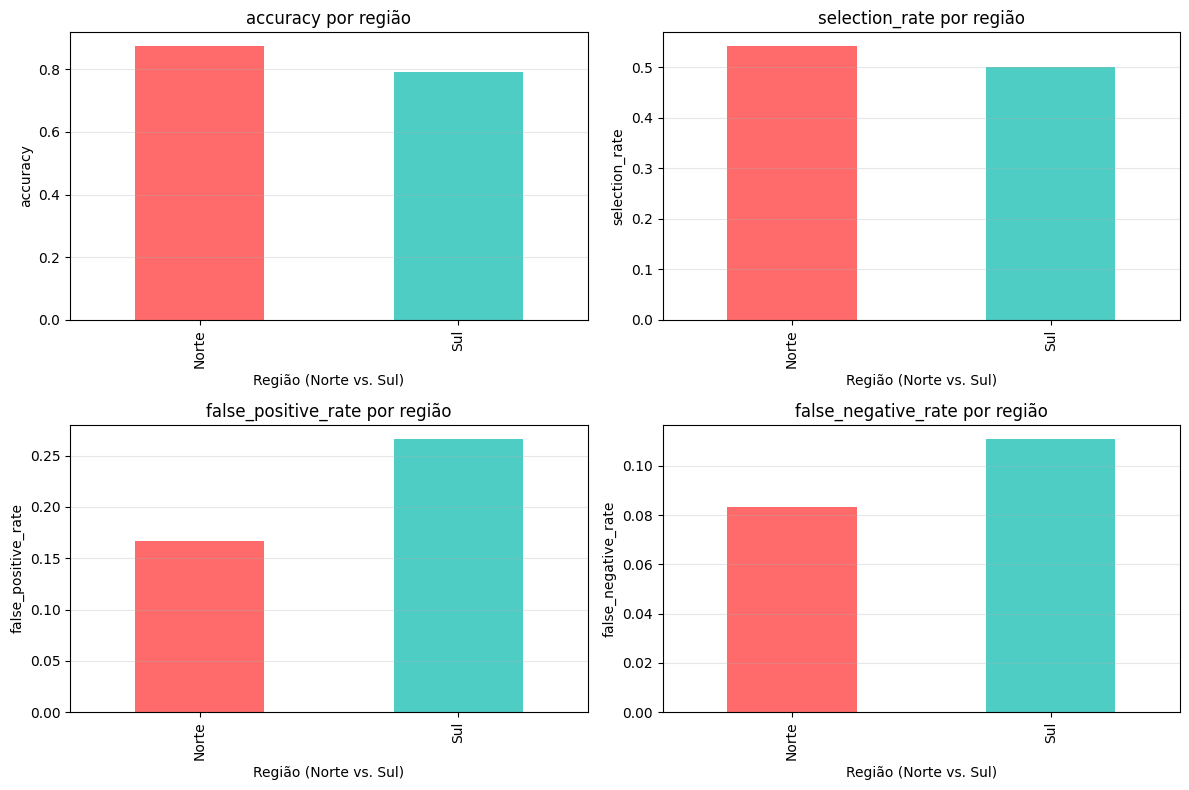

In [14]:
# Visualização de fairness (baseline)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for idx, (metric_name, ax) in enumerate(zip(metric_frame.by_group.columns, axes.flatten())):
    metric_frame.by_group[metric_name].plot(kind='bar', ax=ax, color=['#FF6B6B', '#4ECDC4'])
    ax.set_title(f'{metric_name} por região')
    ax.set_xlabel('Região (Norte vs. Sul)')
    ax.set_ylabel(metric_name)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

- **Acurácia**: A região Norte apresenta acurácia superior (0.875) em relação ao Sul (0.792), com um gap de ~8%, indicando performance desigual.
- **Selection rate**: As taxas de seleção estão relativamente equilibradas (Norte 54% vs. Sul 50%), sugerindo que o volume de aprovações não é o principal problema.
- **Erros**: O viés aparece na taxa de falsos positivos, que é maior no Sul (26.7%) do que no Norte (16.7%). O modelo é mais "moderado" com o Sul, aprovando indevidamente mais clientes de risco.
- **Conclusão**: O modelo demonstra inconsistência na qualidade da decisão entre regiões. A mitigação deve buscar equalizar as taxas de erro (especialmente FPR) para garantir critérios de risco uniformes.

## Mitigação de Viés com *Fairlearn*
Aplicaremos o `ExponentiatedGradient` com a restrição de **False Positive Rate Parity** para reduzir a disparidade de erros do tipo I (falsos positivos) entre as regiões, garantindo que o risco de aprovação indevida seja similar para Norte e Sul.

In [8]:
# Treinar mitigador de viés (Focando em FPR)
X_train_enc = pipeline.named_steps['preprocess'].transform(X_train)
X_test_enc = pipeline.named_steps['preprocess'].transform(X_test)

fair_estimator = LogisticRegression(max_iter=1000, random_state=42)

mitigator = ExponentiatedGradient(
    estimator=fair_estimator,
    constraints=FalsePositiveRateParity(),
    eps=0.01
)

mitigator.fit(X_train_enc, y_train, sensitive_features=X_train['region'])

y_pred_fair = mitigator.predict(X_test_enc)
accuracy_fair = accuracy_score(y_test, y_pred_fair)
print(f"Accuracy após mitigação: {accuracy_fair:.4f}")

Accuracy após mitigação: 0.8125


In [9]:
# Métricas por grupo após mitigação
metric_frame_fair = MetricFrame(
    metrics={
        'accuracy': accuracy_score,
        'selection_rate': selection_rate,
        'false_positive_rate': false_positive_rate,
        'false_negative_rate': false_negative_rate
    },
    y_true=y_test,
    y_pred=y_pred_fair,
    sensitive_features=X_test['region']
 )

print("Métricas por grupo (mitigado):")
print(metric_frame_fair.by_group)

print("\nDiferenças máximas (mitigado):")
print(metric_frame_fair.difference())

comparison = pd.DataFrame({
    'baseline_fpr': metric_frame.by_group['false_positive_rate'],
    'mitigated_fpr': metric_frame_fair.by_group['false_positive_rate']
})
print("\nComparação de FPR por região:")
print(comparison)

Métricas por grupo (mitigado):
        accuracy  selection_rate  false_positive_rate  false_negative_rate
region                                                                    
Norte   0.833333        0.416667             0.083333             0.250000
Sul     0.791667        0.416667             0.200000             0.222222

Diferenças máximas (mitigado):
accuracy               0.041667
selection_rate         0.000000
false_positive_rate    0.116667
false_negative_rate    0.027778
dtype: float64

Comparação de FPR por região:
        baseline_fpr  mitigated_fpr
region                             
Norte       0.166667       0.083333
Sul         0.266667       0.200000


In [ ]:
# Comparar visualmente baseline vs mitigado para FPR
comparison.plot(kind='bar', figsize=(8, 5), color=['#FFB347', '#2ECC71'])
plt.title('FPR por região: baseline vs mitigado')
plt.xlabel('Região')
plt.ylabel('False Positive Rate')
plt.ylim(0, 0.4)  # Escala ajustada para valores de FPR
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Model Card (Documentação do Modelo)

Seguindo o framework do [Google](https://modelcards.withgoogle.com/), vamos criar um Model Card simplificado.

In [10]:
model_card = {
    "model_details": {
        "name": "Credit Approval Model",
        "version": "1.0",
        "date": "2025-11-29",
        "type": "Random Forest Classifier",
        "owner": "Equipe de Risco"
    },
    "intended_use": {
        "primary_use": "Triagem inicial de propostas de crédito",
        "users": "Analistas de crédito",
        "out_of_scope": "Não utilizar como decisão final sem revisão humana"
    },
    "factors": {
        "relevant_factors": "renda, score de crédito, debt_ratio, defaults",
        "evaluation_factors": "Região (Norte/Sul)"
    },
    "metrics": {
        "model_performance": {
            "accuracy": float(accuracy),
            "dataset_size": len(X_test)
        },
        "fairness_metrics": {
            "accuracy_by_region": metric_frame.by_group['accuracy'].to_dict(),
            "max_difference": float(metric_frame.difference()['accuracy'])
        }
    },
    "training_data": {
        "dataset": "Synthetic Credit Approval Demo",
        "size": len(X_train),
        "preprocessing": "StandardScaler para numéricos + OneHotEncoder para categóricos"
    },
    "ethical_considerations": {
        "sensitive_data": "Inclui atributo de região (potencial proxy socioeconômico)",
        "risks": "Possível discriminação contra regiões específicas",
        "mitigations": "Monitorar métricas por região e aplicar Fairlearn quando necessário"
    },
    "recommendations": {
        "ideal_conditions": "Uso combinado com políticas de crédito transparentes",
        "monitoring": "Revisar fairness trimestralmente e validar com stakeholders"
    }
}

# Salvar Model Card
import json
with open('model_card.json', 'w', encoding='utf-8') as f:
    json.dump(model_card, f, indent=2, ensure_ascii=False)

print("Model Card criado e salvo em 'model_card.json'")
print(json.dumps(model_card, indent=2, ensure_ascii=False))

Model Card criado e salvo em 'model_card.json'
{
  "model_details": {
    "name": "Credit Approval Model",
    "version": "1.0",
    "date": "2025-11-29",
    "type": "Random Forest Classifier",
    "owner": "Equipe de Risco"
  },
  "intended_use": {
    "primary_use": "Triagem inicial de propostas de crédito",
    "users": "Analistas de crédito",
    "out_of_scope": "Não utilizar como decisão final sem revisão humana"
  },
  "factors": {
    "relevant_factors": "renda, score de crédito, debt_ratio, defaults",
    "evaluation_factors": "Região (Norte/Sul)"
  },
  "metrics": {
    "model_performance": {
      "accuracy": 0.8333333333333334,
      "dataset_size": 48
    },
    "fairness_metrics": {
      "accuracy_by_region": {
        "Norte": 0.875,
        "Sul": 0.7916666666666666
      },
      "max_difference": 0.08333333333333337
    }
  },
  "training_data": {
    "dataset": "Synthetic Credit Approval Demo",
    "size": 192,
    "preprocessing": "StandardScaler para numéricos + O

## Ciclo de Feedback

Simulação de feedback de usuários para melhoria contínua.

In [11]:
# Simular feedback de profissionais de saúde
# Em produção, isso viria de um sistema real

feedback_data = {
    'prediction_id': [],
    'model_prediction': [],
    'true_outcome': [],
    'feedback_timestamp': [],
    'reviewer': []
}

# Simular 20 feedbacks
np.random.seed(42)
for i in range(20):
    pred_idx = np.random.randint(0, len(y_pred))
    feedback_data['prediction_id'].append(f"PRED_{i:04d}")
    # Usar .iloc para garantir acesso posicional, pois y_pred tem índice do X_test
    feedback_data['model_prediction'].append(int(y_pred.iloc[pred_idx]))
    # 90% de acordo com o ground truth
    if np.random.rand() > 0.1:
        feedback_data['true_outcome'].append(int(y_test.iloc[pred_idx]))
    else:
        feedback_data['true_outcome'].append(1 - int(y_test.iloc[pred_idx]))
    feedback_data['feedback_timestamp'].append(pd.Timestamp.now())
    feedback_data['reviewer'].append(f"Dr. Revisor {i % 5 + 1}")

feedback_df = pd.DataFrame(feedback_data)
feedback_df['correct'] = feedback_df['model_prediction'] == feedback_df['true_outcome']

print("\nFeedback coletado:")
print(feedback_df.head(10))

# Métricas de feedback
feedback_accuracy = feedback_df['correct'].mean()
print(f"\nAccuracy com feedback: {feedback_accuracy:.2%}")
print(f"Predições corretas: {feedback_df['correct'].sum()}/{len(feedback_df)}")


Feedback coletado:
  prediction_id  model_prediction  true_outcome         feedback_timestamp  \
0     PRED_0000                 1             1 2025-11-29 18:18:28.589481   
1     PRED_0001                 0             0 2025-11-29 18:18:28.589541   
2     PRED_0002                 0             0 2025-11-29 18:18:28.589554   
3     PRED_0003                 0             1 2025-11-29 18:18:28.589565   
4     PRED_0004                 0             1 2025-11-29 18:18:28.589573   
5     PRED_0005                 1             1 2025-11-29 18:18:28.589582   
6     PRED_0006                 0             1 2025-11-29 18:18:28.589590   
7     PRED_0007                 1             1 2025-11-29 18:18:28.589598   
8     PRED_0008                 1             1 2025-11-29 18:18:28.589605   
9     PRED_0009                 0             0 2025-11-29 18:18:28.589613   

        reviewer  correct  
0  Dr. Revisor 1     True  
1  Dr. Revisor 2     True  
2  Dr. Revisor 3     True  
3  Dr. Re


Feedback salvo em 'feedback_log.csv'


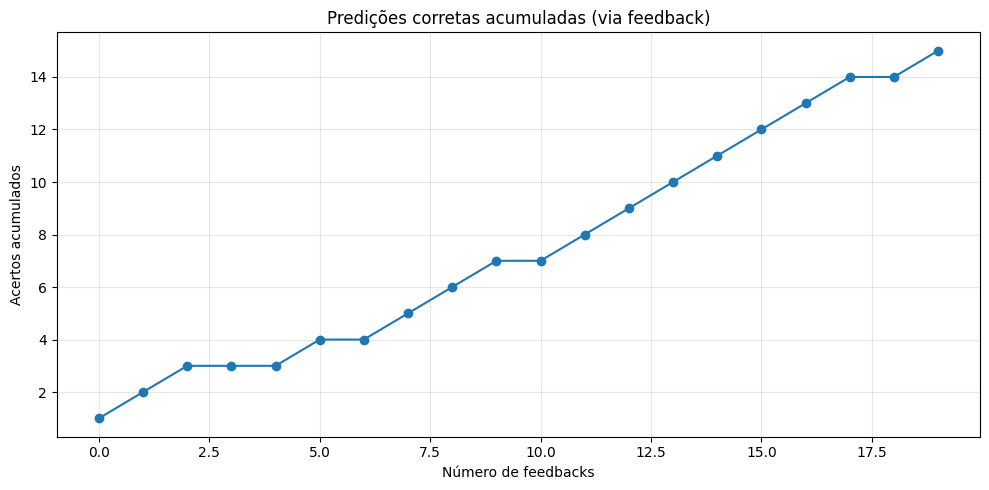

In [12]:
# Salvar feedback para re-treinamento futuro
feedback_df.to_csv('feedback_log.csv', index=False)
print("\nFeedback salvo em 'feedback_log.csv'")

# Visualizar feedback ao longo do tempo
plt.figure(figsize=(10, 5))
feedback_df['correct'].cumsum().plot(marker='o')
plt.title('Predições corretas acumuladas (via feedback)')
plt.xlabel('Número de feedbacks')
plt.ylabel('Acertos acumulados')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Logging no MLflow com Governança

In [13]:
mlflow.set_experiment("governanca_e_feedback")

with mlflow.start_run(run_name="model_with_governance"):
    # Parâmetros
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("random_state", 42)
    
    # Métricas gerais
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("feedback_accuracy", feedback_accuracy)
    
    # Métricas de fairness
    for region, region_accuracy in metric_frame.by_group['accuracy'].items():
        region_key = str(region).lower().replace(' ', '_')
        mlflow.log_metric(f"accuracy_region_{region_key}", region_accuracy)
    
    mlflow.log_metric("fairness_accuracy_diff", float(metric_frame.difference()['accuracy']))
    
    # Artifacts
    mlflow.log_artifact('model_card.json')
    mlflow.log_artifact('feedback_log.csv')
    
    # Modelo
    mlflow.sklearn.log_model(pipeline, "model")
    
    print("\n✓ Modelo, Model Card e Feedback registrados no MLflow")

2025/11/29 18:18:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/11/29 18:18:38 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2025/11/29 18:18:38 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



✓ Modelo, Model Card e Feedback registrados no MLflow
